<a href="https://colab.research.google.com/github/prabhusanika24/CSL701-ce37_Machine-Learning-Lab/blob/main/Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name:Sanika Janardan Prabhu
Rollno:CE37

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for plotting

# Scikit-learn imports
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Display sklearn version
print("Scikit-learn version:", sklearn.__version__)

# Column names for the Pima Indians Diabetes dataset
columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

# Download the dataset if not already present
file_path = "pima-indians-diabetes.csv" # Updated file name
!wget -nc https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv -O {file_path} # Updated URL and output file name

# Load the dataset
df = pd.read_csv(file_path, header=None, names=columns)

# First five records
print("First five records:")
display(df.head())

# Dataset shape
print("\nDataset shape:", df.shape)

# Data types
print("\nData types:")
print(df.dtypes)

# Descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

Scikit-learn version: 1.6.1
File ‘pima-indians-diabetes.csv’ already there; not retrieving.
First five records:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Dataset shape: (768, 9)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Descriptive statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages (Outcome):
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


/tmp/ipykernel_3729/1585919220.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='viridis')


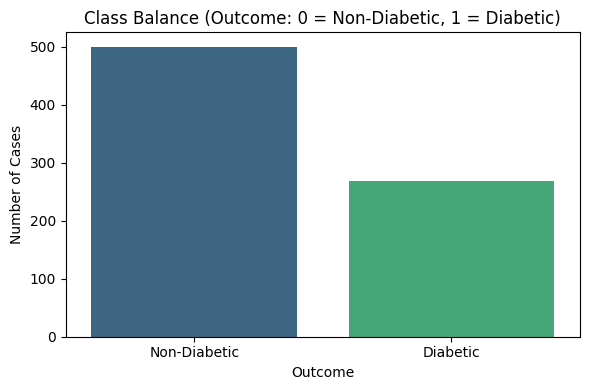

In [ ]:
# Calculate absolute count and percentage of diabetic and non-diabetic cases
class_counts = df['Outcome'].value_counts()
class_percentages = df['Outcome'].value_counts(normalize=True) * 100

print("Class Counts (Outcome):")
print(class_counts)
print("\nClass Percentages (Outcome):")
print(class_percentages)

# Plot the class balance using a bar chart
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='viridis')
ax.set_title('Class Balance (Outcome: 0 = Non-Diabetic, 1 = Diabetic)')
ax.set_xlabel('Outcome')
ax.set_ylabel('Number of Cases')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.show()

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [ ]:
# Features where a value of 0 is physically impossible
features_with_impossible_zeros = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("Original descriptive statistics (showing 0 values):")
display(df[features_with_impossible_zeros].describe())

# Replace 0 values with NaN in the specified features
for feature in features_with_impossible_zeros:
    df[feature] = df[feature].replace(0, np.nan)

print("\nNumber of NaN values after replacing 0s:")
print(df[features_with_impossible_zeros].isnull().sum())

# Handle missing values by imputing with the median
for feature in features_with_impossible_zeros:
    median_val = df[feature].median()
    df[feature] = df[feature].fillna(median_val)

print("\nNumber of NaN values after median imputation:")
print(df[features_with_impossible_zeros].isnull().sum())

print("\nDescriptive statistics after handling missing values:")
display(df[features_with_impossible_zeros].describe())

Original descriptive statistics (showing 0 values):


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000



Number of NaN values after replacing 0s:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Number of NaN values after median imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Descriptive statistics after handling missing values:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [ ]:
# Isolate feature matrix X and target vector y
X = df.iloc[:, :-1]  # All columns except the last one
y = df.iloc[:, -1]   # The last column is the target

# Split the dataset into 80% training and 20% test data
# Use stratified sampling to preserve class proportions in y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True))
print("\nClass distribution in y_train:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)

Class distribution in original dataset:
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Class distribution in y_train:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class distribution in y_test:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [ ]:
def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (sampling with replacement) from the given data.

    Args:
        X (pd.DataFrame): The feature matrix.
        y (pd.Series): The target vector.

    Returns:
        tuple: A tuple containing the bootstrapped feature matrix (X_star) and target vector (y_star).
    """
    n_samples = X.shape[0] # Get the number of samples from the training set
    # Generate n_samples random indices with replacement
    bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)

    X_star = X.iloc[bootstrap_indices]
    y_star = y.iloc[bootstrap_indices]

    return X_star, y_star

# --- Verification of the function ---
print("\n--- Verifying get_bootstrap_sample function ---")

# Generate a sample bootstrap from X_train and y_train
np.random.seed(42) # for reproducibility of the demonstration
X_boot, y_boot = get_bootstrap_sample(X_train, y_train)

print(f"Original training set size: {X_train.shape[0]}")
print(f"Bootstrap sample set size: {X_boot.shape[0]}")

# To verify, we need the original indices. Let's create a temporary DataFrame/Series with original indices for easy comparison.
original_indices = X_train.index.values
bootstrap_sample_indices = X_boot.index.values

# 1. Demonstrate duplicated indices
from collections import Counter
index_counts = Counter(bootstrap_sample_indices)

duplicated_indices = {idx: count for idx, count in index_counts.items() if count > 1}

if duplicated_indices:
    print(f"\nSome original row indices are duplicated in the bootstrap sample (showing first 5 if many):\n{dict(list(duplicated_indices.items())[:5])}")
else:
    print("\nNo duplicated indices found (this is unlikely for a proper bootstrap sample).")

# 2. Demonstrate omitted (Out-of-Bag) indices
all_original_indices_set = set(original_indices)
bootstrap_sample_indices_set = set(bootstrap_sample_indices)

omitted_indices = list(all_original_indices_set - bootstrap_sample_indices_set)

if omitted_indices:
    print(f"\nSome original row indices are omitted (Out-of-Bag) (showing first 5 if many):\n{omitted_indices[:5]}")
else:
    print("\nNo omitted (Out-of-Bag) indices found (this is unlikely for a proper bootstrap sample).")

print("--- Verification Complete ---")


--- Verifying get_bootstrap_sample function ---
Original training set size: 614
Bootstrap sample set size: 614

Some original row indices are duplicated in the bootstrap sample (showing first 5 if many):
{np.int64(651): 2, np.int64(708): 2, np.int64(464): 2, np.int64(625): 2, np.int64(200): 2}

Some original row indices are omitted (Out-of-Bag) (showing first 5 if many):
[np.int64(0), np.int64(2), np.int64(514), np.int64(515), np.int64(5)]
--- Verification Complete ---


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [ ]:
# 1. Initialize an empty list to store the trained models
ensemble_models = []

# Choose the number of bootstrap iterations
B = 50  # Number of base classifiers in the ensemble

print(f"Training an ensemble of {B} Decision Tree Classifiers...")

# 2. Execute the steps for B iterations
for i in range(B):
    # a. Generate a unique bootstrap training dataset
    X_star_b, y_star_b = get_bootstrap_sample(X_train, y_train)

    # b. Instantiate a Scikit-Learn DecisionTreeClassifier with max_depth=None
    # This ensures that the decision trees are fully grown, resulting in high-variance base learners.
    model_b = DecisionTreeClassifier(max_depth=None, random_state=i) # Using i for random_state for diversity

    # c. Fit the decision tree on the bootstrapped training subset
    model_b.fit(X_star_b, y_star_b)

    # d. Append the trained model to the ensemble list
    ensemble_models.append(model_b)

print(f"Ensemble training complete. Total models in ensemble: {len(ensemble_models)}")

Training an ensemble of 50 Decision Tree Classifiers...
Ensemble training complete. Total models in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [ ]:
def custom_bagging_predict(ensemble, X_test):
    """
    Generates predictions for X_test using an ensemble of models with majority voting.

    Args:
        ensemble (list): A list of trained base models (e.g., DecisionTreeClassifier instances).
        X_test (pd.DataFrame): The feature matrix for which to make predictions.

    Returns:
        np.ndarray: The final majority-voted predictions (0s or 1s) for each sample in X_test.
    """
    # Collect predictions from all models in the ensemble
    all_predictions = np.array([model.predict(X_test) for model in ensemble])

    # Transpose the array to have (n_samples, n_estimators)
    # Each row corresponds to a test sample, each column to a model's prediction
    all_predictions = all_predictions.T

    # Apply majority voting for each sample
    final_predictions = np.array([
        np.round(np.mean(sample_predictions)) # For binary classification, mean >= 0.5 can be 1, else 0
        for sample_predictions in all_predictions
    ])

    return final_predictions.astype(int)

print("Custom Bagging Predict function defined. We can now use it to make predictions.")

Custom Bagging Predict function defined. We can now use it to make predictions.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


--- Training and Evaluating Single Decision Tree ---

--- Single Decision Tree Performance ---

Confusion Matrix (Single Tree):


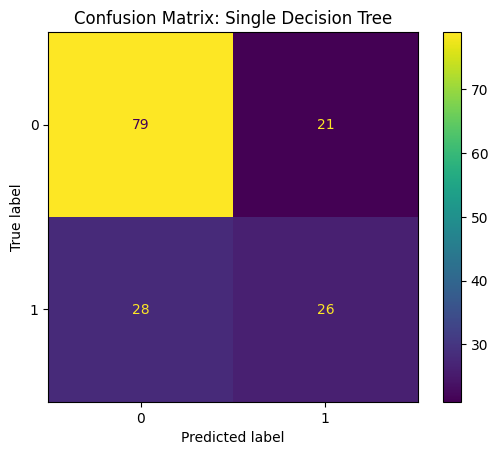

Accuracy (Single Tree): 0.6818
Precision (Single Tree): 0.5532
Recall (Single Tree): 0.4815
F1-Score (Single Tree): 0.5149

--- Custom Bagging Classifier Performance ---

Confusion Matrix (Bagging Ensemble):


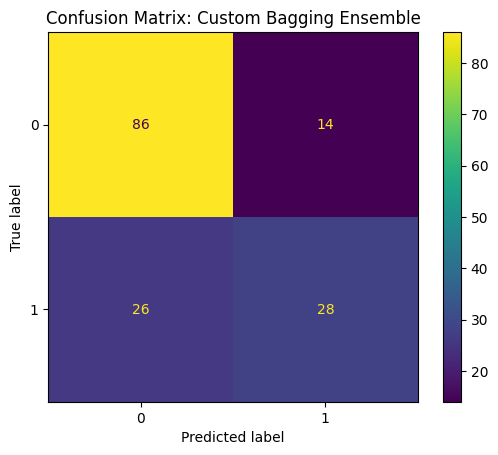

Accuracy (Bagging Ensemble): 0.7403
Precision (Bagging Ensemble): 0.6667
Recall (Bagging Ensemble): 0.5185
F1-Score (Bagging Ensemble): 0.5833

--- Performance Comparison Complete ---


In [ ]:
# 1. Train a standalone, single DecisionTreeClassifier (fully grown, no depth limit)
print("\n--- Training and Evaluating Single Decision Tree ---")
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree_model.fit(X_train, y_train)

# 2. Predict the classes for X_test using both the single tree and your custom Bagging classifier
single_tree_predictions = single_tree_model.predict(X_test)
bagging_predictions = custom_bagging_predict(ensemble_models, X_test)

# 3. Construct a Confusion Matrix for both models and 4. Compute and print metrics

# --- Single Decision Tree Performance ---
print("\n--- Single Decision Tree Performance ---")
print("\nConfusion Matrix (Single Tree):")
cm_single = confusion_matrix(y_test, single_tree_predictions)
display_cm_single = ConfusionMatrixDisplay(confusion_matrix=cm_single, display_labels=[0, 1])
display_cm_single.plot()
plt.title('Confusion Matrix: Single Decision Tree')
plt.show()

accuracy_single = accuracy_score(y_test, single_tree_predictions)
precision_single = precision_score(y_test, single_tree_predictions)
recall_single = recall_score(y_test, single_tree_predictions)
f1_single = f1_score(y_test, single_tree_predictions)

print(f"Accuracy (Single Tree): {accuracy_single:.4f}")
print(f"Precision (Single Tree): {precision_single:.4f}")
print(f"Recall (Single Tree): {recall_single:.4f}")
print(f"F1-Score (Single Tree): {f1_single:.4f}")

# --- Custom Bagging Classifier Performance ---
print("\n--- Custom Bagging Classifier Performance ---")
print("\nConfusion Matrix (Bagging Ensemble):")
cm_bagging = confusion_matrix(y_test, bagging_predictions)
display_cm_bagging = ConfusionMatrixDisplay(confusion_matrix=cm_bagging, display_labels=[0, 1])
display_cm_bagging.plot()
plt.title('Confusion Matrix: Custom Bagging Ensemble')
plt.show()

accuracy_bagging = accuracy_score(y_test, bagging_predictions)
precision_bagging = precision_score(y_test, bagging_predictions)
recall_bagging = recall_score(y_test, bagging_predictions)
f1_bagging = f1_score(y_test, bagging_predictions)

print(f"Accuracy (Bagging Ensemble): {accuracy_bagging:.4f}")
print(f"Precision (Bagging Ensemble): {precision_bagging:.4f}")
print(f"Recall (Bagging Ensemble): {recall_bagging:.4f}")
print(f"F1-Score (Bagging Ensemble): {f1_bagging:.4f}")

print("\n--- Performance Comparison Complete ---")

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

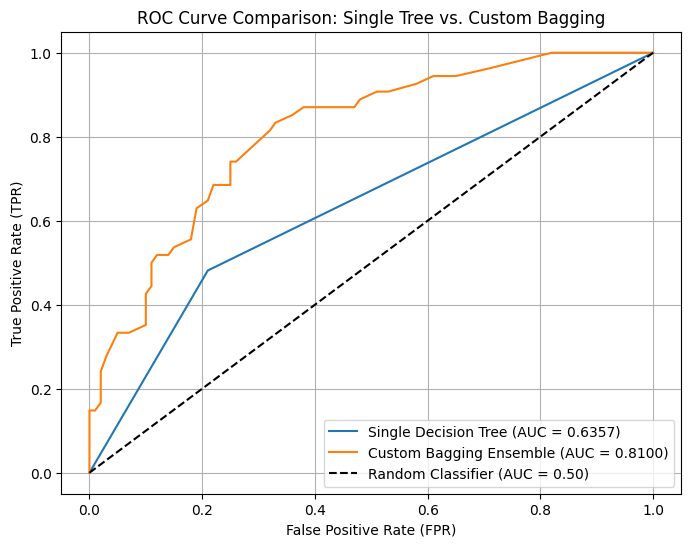


ROC-AUC Score (Single Decision Tree): 0.6357
ROC-AUC Score (Custom Bagging Ensemble): 0.8100

--- ROC-AUC Analysis Complete ---


In [ ]:
# 1. Calculate predicted class probabilities for the single decision tree
single_tree_probs = single_tree_model.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

# 2. Calculate predicted class probabilities for the custom Bagging model
# This involves averaging the probability estimates across all B decision trees
bagging_probs = np.array([model.predict_proba(X_test)[:, 1] for model in ensemble_models]).mean(axis=0)

# 3. Plot the Receiver Operating Characteristic (ROC) curve for both models

# Calculate ROC curve points for single tree
fpr_single, tpr_single, _ = roc_curve(y_test, single_tree_probs)
auc_single = roc_auc_score(y_test, single_tree_probs)

# Calculate ROC curve points for bagging ensemble
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, bagging_probs)
auc_bagging = roc_auc_score(y_test, bagging_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_single, tpr_single, label=f'Single Decision Tree (AUC = {auc_single:.4f})')
plt.plot(fpr_bagging, tpr_bagging, label=f'Custom Bagging Ensemble (AUC = {auc_bagging:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison: Single Tree vs. Custom Bagging')
plt.legend()
plt.grid(True)
plt.show()

# 4. Compute and contrast the Area Under the Curve (AUC)
print(f"\nROC-AUC Score (Single Decision Tree): {auc_single:.4f}")
print(f"ROC-AUC Score (Custom Bagging Ensemble): {auc_bagging:.4f}")

print("\n--- ROC-AUC Analysis Complete ---")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.


--- Validating against Scikit-Learn's BaggingClassifier ---

--- Scikit-Learn BaggingClassifier Performance ---

Confusion Matrix (Scikit-Learn Bagging):


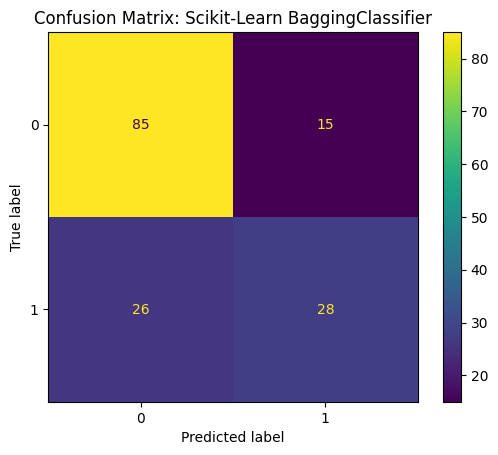

Accuracy (Scikit-Learn Bagging): 0.7338
Precision (Scikit-Learn Bagging): 0.6512
Recall (Scikit-Learn Bagging): 0.5185
F1-Score (Scikit-Learn Bagging): 0.5773

--- Comparison of Custom vs. Scikit-Learn Bagging ---
Custom Bagging Accuracy:    0.7403
Scikit-Learn Bagging Accuracy: 0.7338

--- Validation Complete ---


In [ ]:
from sklearn.ensemble import BaggingClassifier

print("\n--- Validating against Scikit-Learn's BaggingClassifier ---")

# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
# Use DecisionTreeClassifier(max_depth=None) as the base estimator and n_estimators=50
# Use random_state for reproducibility
sk_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42, # Set random_state for reproducibility
    bootstrap=True,  # Explicitly set bootstrap to True (default)
    oob_score=False, # We are not using OOB score for this comparison
    n_jobs=-1        # Use all available cores for training
)

# 2. Fit the classifier on the training set
sk_bagging_model.fit(X_train, y_train)

# Make predictions on the test set
sk_bagging_predictions = sk_bagging_model.predict(X_test)

# 3. Compare the resulting test accuracy and confusion matrix

# --- Scikit-Learn BaggingClassifier Performance ---
print("\n--- Scikit-Learn BaggingClassifier Performance ---")
print("\nConfusion Matrix (Scikit-Learn Bagging):")
cm_sk_bagging = confusion_matrix(y_test, sk_bagging_predictions)
display_cm_sk_bagging = ConfusionMatrixDisplay(confusion_matrix=cm_sk_bagging, display_labels=[0, 1])
display_cm_sk_bagging.plot()
plt.title('Confusion Matrix: Scikit-Learn BaggingClassifier')
plt.show()

accuracy_sk_bagging = accuracy_score(y_test, sk_bagging_predictions)
precision_sk_bagging = precision_score(y_test, sk_bagging_predictions)
recall_sk_bagging = recall_score(y_test, sk_bagging_predictions)
f1_sk_bagging = f1_score(y_test, sk_bagging_predictions)

print(f"Accuracy (Scikit-Learn Bagging): {accuracy_sk_bagging:.4f}")
print(f"Precision (Scikit-Learn Bagging): {precision_sk_bagging:.4f}")
print(f"Recall (Scikit-Learn Bagging): {recall_sk_bagging:.4f}")
print(f"F1-Score (Scikit-Learn Bagging): {f1_sk_bagging:.4f}")

print("\n--- Comparison of Custom vs. Scikit-Learn Bagging ---")
print(f"Custom Bagging Accuracy:    {accuracy_bagging:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {accuracy_sk_bagging:.4f}")

print("\n--- Validation Complete ---")

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?